# Text Mining & Image Recognition — Laboratorio No. 4

## Comparación de una red neuronal artificial y una red neuronal convolucional para MNIST

Este notebook construye, entrena y evalúa dos clasificadores multiclase de dígitos manuscritos (0–9) a partir de `train.csv`:

1. **ANN:** red neuronal artificial totalmente conectada.
2. **CNN:** red neuronal convolucional que explota la estructura espacial de las imágenes.

La implementación sigue las guías de clase: TensorFlow/Keras, modelos secuenciales, normalización de píxeles, bloques convolucionales con *max pooling*, capa `Flatten`, activación `ReLU`, salida `Softmax`, optimizador Adam y entropía cruzada. La comparación usa exactamente el mismo conjunto de prueba para ambos modelos.

## Resumen ejecutivo

La **CNN fue el mejor enfoque**: obtuvo 98.89% de exactitud y 98.88% de F1 macro en 8,400 imágenes de prueba, frente a 97.13% y 97.11% de la ANN. Esto equivale a 148 errores menos (93 frente a 241), aunque la CNN tardó 81.75 s en entrenarse frente a 5.17 s de la ANN. La comparación considera calidad predictiva, pérdida, tiempo y complejidad; F1 macro es la métrica principal porque pondera por igual las diez clases.

## Contexto y métodos

### 1. Configuración reproducible

In [1]:
# Esta celda debe ejecutarse antes de importar TensorFlow o Matplotlib.
import os
from pathlib import Path

BASE_DIR = Path.cwd()
os.environ["MPLCONFIGDIR"] = str(BASE_DIR / ".cache" / "matplotlib")
os.environ["KERAS_HOME"] = str(BASE_DIR / ".cache" / "keras")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["KERAS_HOME"]).mkdir(parents=True, exist_ok=True)

SEED = 42
TEST_SIZE = 0.20
VALIDATION_SPLIT = 0.10
BATCH_SIZE = 128
MAX_EPOCHS = 10

print(f"Directorio de trabajo: {BASE_DIR}")
print(f"Semilla: {SEED} | Prueba: {TEST_SIZE:.0%} | Validación interna: {VALIDATION_SPLIT:.0%}")

Directorio de trabajo: C:\Users\rfarfan\OneDrive - Universidad Galileo\2026T3\Text Mining & Image Recognition\Repositorio GIT Text Mining RF\Laboratorio 4
Semilla: 42 | Prueba: 20% | Validación interna: 10%


In [2]:
import json
import platform
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore", category=FutureWarning)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"ANN": "#355C8A", "CNN": "#D18B2C"}

print(f"Python: {platform.python_version()}")
print(f"TensorFlow: {tf.__version__} | Keras: {tf.keras.__version__}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Dispositivos GPU detectados: {len(tf.config.list_physical_devices('GPU'))}")

Python: 3.12.10
TensorFlow: 2.21.0 | Keras: 3.15.1
pandas: 3.0.5 | NumPy: 2.5.2 | scikit-learn: 1.9.0


Dispositivos GPU detectados: 0


### Decisiones metodológicas

- Se usa una división estratificada **80/20** con semilla fija para que las diez clases mantengan proporciones similares.
- El 10% del conjunto de entrenamiento se reserva internamente para validación y parada temprana; el conjunto de prueba permanece intacto hasta la evaluación final.
- Los píxeles se convierten de enteros `[0,255]` a `float32` en `[0,1]`.
- Todas las filas se reconstruyen primero como imágenes `28×28×1`. La ANN aplana esas imágenes dentro del modelo; la CNN conserva su geometría para aprender patrones espaciales.
- Ambos modelos usan Adam, `sparse_categorical_crossentropy`, lotes de 128 y el mismo límite de épocas. La parada temprana restaura los mejores pesos según la pérdida de validación.
- No se aplica *data augmentation*: rotaciones o volteos pueden cambiar la identidad o semántica de algunos dígitos y complicar una comparación controlada.

Estas decisiones permiten una comparación reproducible sin debilitar artificialmente ninguno de los dos enfoques.

## Datos

### 2. Carga y validación del archivo

In [3]:
csv_path = BASE_DIR / "train.csv"
if not csv_path.exists():
    candidates = list(BASE_DIR.rglob("train.csv"))
    if len(candidates) != 1:
        raise FileNotFoundError("No se encontró un único archivo train.csv.")
    csv_path = candidates[0]

data = pd.read_csv(csv_path, dtype=np.uint8)
expected_pixels = [f"pixel{i}" for i in range(784)]

assert data.shape[1] == 785, f"Se esperaban 785 columnas y se encontraron {data.shape[1]}."
assert data.columns[0] == "label", "La primera columna debe llamarse 'label'."
assert data.columns[1:].tolist() == expected_pixels, "Las columnas pixel0...pixel783 no están en el orden esperado."
assert not data.isna().any().any(), "El dataset contiene valores faltantes."
assert data["label"].between(0, 9).all(), "Se encontraron etiquetas fuera del rango 0–9."
assert data.iloc[:, 1:].to_numpy().min() >= 0 and data.iloc[:, 1:].to_numpy().max() <= 255

print(f"Fuente: {csv_path.name}")
print(f"Dimensiones: {data.shape[0]:,} filas × {data.shape[1]:,} columnas")
print(f"Valores faltantes: {int(data.isna().sum().sum())}")
print(f"Duplicados exactos: {int(data.duplicated().sum())}")
print(f"Rango de píxeles: {int(data.iloc[:, 1:].min().min())}–{int(data.iloc[:, 1:].max().max())}")
display(data.head())

Fuente: train.csv
Dimensiones: 42,000 filas × 785 columnas
Valores faltantes: 0


Duplicados exactos: 0
Rango de píxeles: 0–255


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,cantidad,porcentaje
label,,
0,4132,9.84
1,4684,11.15
2,4177,9.95
3,4351,10.36
4,4072,9.70
5,3795,9.04
6,4137,9.85
7,4401,10.48
8,4063,9.67


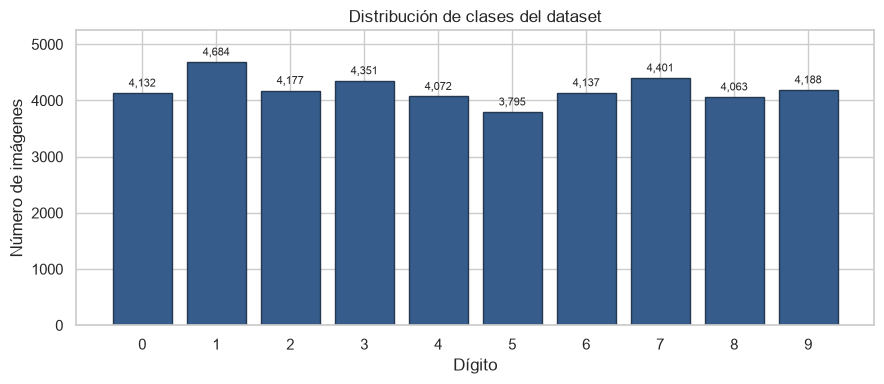

In [4]:
class_counts = data["label"].value_counts().sort_index().rename("cantidad").to_frame()
class_counts["porcentaje"] = 100 * class_counts["cantidad"] / len(data)
class_counts_display = class_counts.copy()
class_counts_display["porcentaje"] = class_counts_display["porcentaje"].round(2)
display(class_counts_display)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(class_counts.index.astype(str), class_counts["cantidad"], color="#355C8A", edgecolor="#24384F")
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=8)
ax.set(title="Distribución de clases del dataset", xlabel="Dígito", ylabel="Número de imágenes")
ax.set_ylim(0, class_counts["cantidad"].max() * 1.12)
plt.tight_layout()
plt.show()

### 3. Reconstrucción de imágenes 28×28

Matriz tabular normalizada: (42000, 784)
Tensor de imágenes: (42000, 28, 28, 1)
Rango normalizado: 0.0–1.0


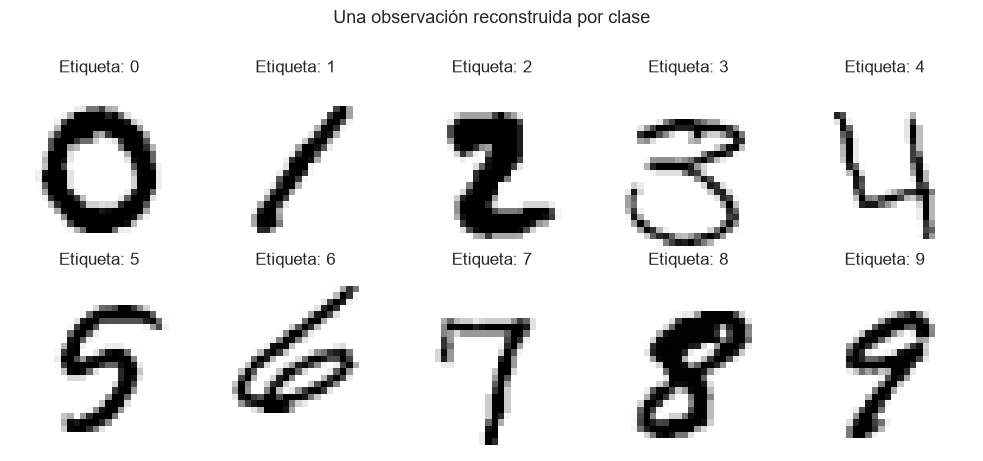

In [5]:
labels_array = data["label"].to_numpy(dtype=np.int64)
pixels_flat = data.iloc[:, 1:].to_numpy(dtype=np.float32) / 255.0
images = pixels_flat.reshape(-1, 28, 28, 1)

print(f"Matriz tabular normalizada: {pixels_flat.shape}")
print(f"Tensor de imágenes: {images.shape}")
print(f"Rango normalizado: {images.min():.1f}–{images.max():.1f}")

fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
for digit, ax in enumerate(axes.ravel()):
    idx = np.flatnonzero(labels_array == digit)[0]
    ax.imshow(images[idx, :, :, 0], cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"Etiqueta: {digit}")
    ax.axis("off")
fig.suptitle("Una observación reconstruida por clase", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### 4. División estratificada de entrenamiento y prueba

In [6]:
all_indices = np.arange(len(labels_array))
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=labels_array,
)

X_train = images[train_indices]
X_test = images[test_indices]
y_train = labels_array[train_indices]
y_test = labels_array[test_indices]

del pixels_flat, images, data

split_summary = pd.DataFrame({
    "porción": ["Entrenamiento", "Prueba"],
    "imágenes": [len(y_train), len(y_test)],
    "porcentaje": [100 * len(y_train) / len(labels_array), 100 * len(y_test) / len(labels_array)],
})
display(split_summary.round({"porcentaje": 1}))

train_distribution = np.bincount(y_train, minlength=10) / len(y_train)
test_distribution = np.bincount(y_test, minlength=10) / len(y_test)
print(f"Máxima diferencia de proporción entre entrenamiento y prueba: {np.max(np.abs(train_distribution-test_distribution)):.4%}")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

,porción,imágenes,porcentaje
0,Entrenamiento,33600,80.0
1,Prueba,8400,20.0


Máxima diferencia de proporción entre entrenamiento y prueba: 0.0089%
X_train: (33600, 28, 28, 1) | X_test: (8400, 28, 28, 1)


## Modelos

### 5. Arquitectura de la red neuronal artificial (ANN)

In [7]:
def build_ann():
    model = keras.Sequential(
        [
            layers.Input(shape=(28, 28, 1), name="imagen_entrada"),
            layers.Flatten(name="aplanamiento"),
            layers.Dense(128, activation="relu", name="densa_128"),
            layers.Dropout(0.20, name="dropout_20"),
            layers.Dense(64, activation="relu", name="densa_64"),
            layers.Dropout(0.20, name="dropout_20_b"),
            layers.Dense(10, activation="softmax", name="salida_10_clases"),
        ],
        name="ANN_MNIST",
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


ann_model = build_ann()
ann_model.summary()

Model: "ANN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aplanamiento (Flatten)          │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_128 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20_b (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_10_clases (Dense)        │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

La ANN recibe la misma imagen `28×28×1`, pero `Flatten` elimina la estructura espacial antes de las capas densas. Las dos capas `Dropout` reducen el riesgo de sobreajuste. La salida tiene diez neuronas `Softmax`, una por dígito.

### 6. Arquitectura de la red neuronal convolucional (CNN)

In [8]:
def build_cnn():
    model = keras.Sequential(
        [
            layers.Input(shape=(28, 28, 1), name="imagen_entrada"),
            layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="conv_32"),
            layers.MaxPooling2D((2, 2), name="pool_1"),
            layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="conv_64"),
            layers.MaxPooling2D((2, 2), name="pool_2"),
            layers.Flatten(name="aplanamiento"),
            layers.Dense(128, activation="relu", name="densa_128"),
            layers.Dropout(0.30, name="dropout_30"),
            layers.Dense(10, activation="softmax", name="salida_10_clases"),
        ],
        name="CNN_MNIST",
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


cnn_model = build_cnn()
cnn_model.summary()

Model: "CNN_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_32 (Conv2D)                │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_64 (Conv2D)                │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ aplanamiento (Flatten)          │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa_128 (Dense)               │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_10_clases (Dense)        │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

La CNN sigue el patrón de clase: dos bloques de convolución y *max pooling*, seguidos de aplanamiento y clasificación densa. Los filtros `3×3` extraen patrones locales; el *pooling* conserva características dominantes y reduce la dimensionalidad.

## Resultados

### 7. Entrenamiento controlado

In [9]:
def make_callbacks():
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=2, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5, verbose=1
        ),
    ]


training_histories = {}
training_times = {}

for model_name, model in [("ANN", ann_model), ("CNN", cnn_model)]:
    print(f"\n{'=' * 24} Entrenamiento {model_name} {'=' * 24}")
    start_time = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_split=VALIDATION_SPLIT,
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=2,
        shuffle=True,
    )
    training_times[model_name] = time.perf_counter() - start_time
    training_histories[model_name] = history.history
    print(f"Tiempo de entrenamiento {model_name}: {training_times[model_name]:.2f} s")


======================== Entrenamiento ANN ========================
Epoch 1/10


237/237 - 1s - 5ms/step - accuracy: 0.8198 - loss: 0.5967 - val_accuracy: 0.9295 - val_loss: 0.2359 - learning_rate: 0.0010


Epoch 2/10


237/237 - 0s - 2ms/step - accuracy: 0.9233 - loss: 0.2563 - val_accuracy: 0.9467 - val_loss: 0.1745 - learning_rate: 0.0010


Epoch 3/10


...

Epoch 10/10



Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.


237/237 - 8s - 35ms/step - accuracy: 0.9956 - loss: 0.0159 - val_accuracy: 0.9878 - val_loss: 0.0463 - learning_rate: 2.5000e-04


Restoring model weights from the end of the best epoch: 9.


Tiempo de entrenamiento CNN: 81.75 s


### 8. Curvas de aprendizaje

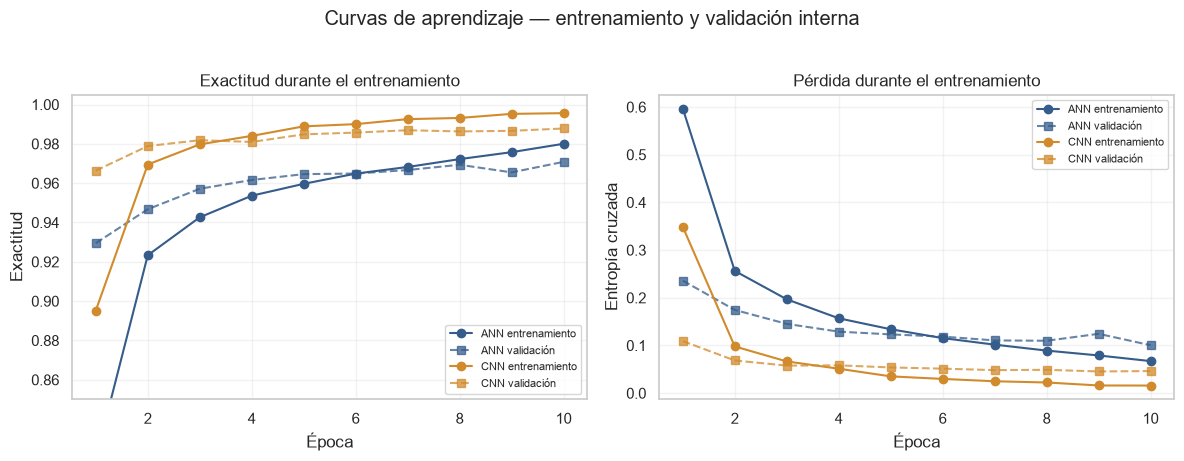

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for model_name, history in training_histories.items():
    epochs = np.arange(1, len(history["loss"]) + 1)
    axes[0].plot(epochs, history["accuracy"], marker="o", color=PALETTE[model_name], label=f"{model_name} entrenamiento")
    axes[0].plot(epochs, history["val_accuracy"], marker="s", linestyle="--", color=PALETTE[model_name], alpha=0.75, label=f"{model_name} validación")
    axes[1].plot(epochs, history["loss"], marker="o", color=PALETTE[model_name], label=f"{model_name} entrenamiento")
    axes[1].plot(epochs, history["val_loss"], marker="s", linestyle="--", color=PALETTE[model_name], alpha=0.75, label=f"{model_name} validación")

axes[0].set(title="Exactitud durante el entrenamiento", xlabel="Época", ylabel="Exactitud", ylim=(0.85, 1.005))
axes[1].set(title="Pérdida durante el entrenamiento", xlabel="Época", ylabel="Entropía cruzada")
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
fig.suptitle("Curvas de aprendizaje — entrenamiento y validación interna", y=1.02)
plt.tight_layout()
plt.savefig(BASE_DIR / "curvas_aprendizaje.png", dpi=180, bbox_inches="tight")
plt.show()

### 9. Evaluación final sobre el conjunto de prueba

In [11]:
models = {"ANN": ann_model, "CNN": cnn_model}
predictions = {}
probabilities = {}
evaluation_rows = []

for model_name, model in models.items():
    start_time = time.perf_counter()
    probabilities[model_name] = model.predict(X_test, batch_size=256, verbose=0)
    inference_seconds = time.perf_counter() - start_time
    predictions[model_name] = probabilities[model_name].argmax(axis=1)
    y_pred = predictions[model_name]
    evaluation_rows.append(
        {
            "Modelo": model_name,
            "Exactitud": accuracy_score(y_test, y_pred),
            "Precisión macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "Recall macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "F1 macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Pérdida logarítmica": log_loss(y_test, probabilities[model_name], labels=np.arange(10)),
            "Tiempo entrenamiento (s)": training_times[model_name],
            "Tiempo inferencia prueba (s)": inference_seconds,
            "Parámetros": model.count_params(),
            "Épocas ejecutadas": len(training_histories[model_name]["loss"]),
        }
    )

metrics_df = pd.DataFrame(evaluation_rows).set_index("Modelo")
metrics_df.to_csv(BASE_DIR / "resultados_metricas.csv", encoding="utf-8-sig")

metrics_display = metrics_df.copy()
score_columns = ["Exactitud", "Precisión macro", "Recall macro", "F1 macro", "Pérdida logarítmica"]
metrics_display[score_columns] = metrics_display[score_columns].round(4)
time_columns = ["Tiempo entrenamiento (s)", "Tiempo inferencia prueba (s)"]
metrics_display[time_columns] = metrics_display[time_columns].round(2)
display(metrics_display)

,Exactitud,Precisión macro,Recall macro,F1 macro,Pérdida logarítmica,Tiempo entrenamiento (s),Tiempo inferencia prueba (s),Parámetros,Épocas ejecutadas
Modelo,,,,,,,,,
ANN,0.9713,0.9710,0.9711,0.9711,0.0971,5.17,0.11,109386,10
CNN,0.9889,0.9888,0.9889,0.9888,0.0407,81.75,0.58,421642,10


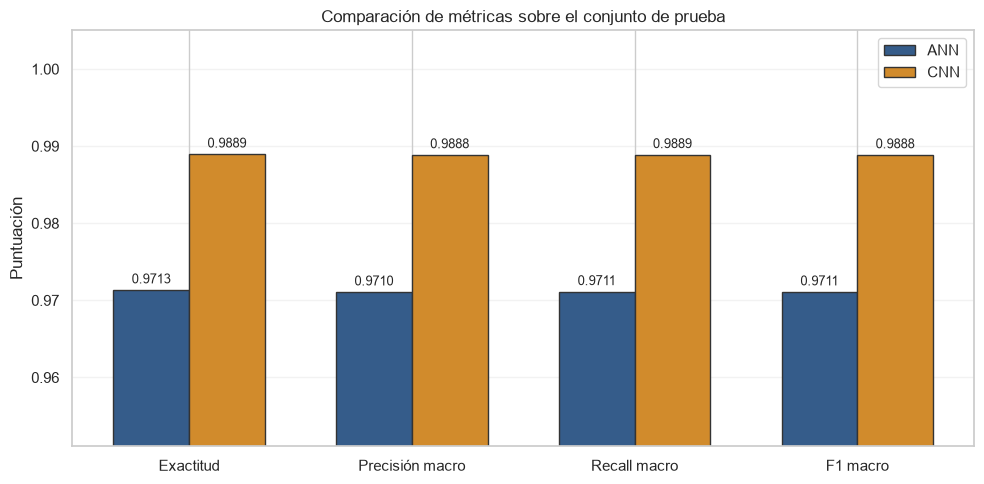

In [12]:
metric_columns = ["Exactitud", "Precisión macro", "Recall macro", "F1 macro"]
plot_metrics = metrics_df[metric_columns].T

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metric_columns))
width = 0.34
for offset, model_name in zip([-width / 2, width / 2], ["ANN", "CNN"]):
    values = plot_metrics[model_name].to_numpy()
    bars = ax.bar(x + offset, values, width, label=model_name, color=PALETTE[model_name], edgecolor="#333333")
    ax.bar_label(bars, labels=[f"{v:.4f}" for v in values], padding=3, fontsize=9)

ax.set_xticks(x, metric_columns)
ax.set_ylim(max(0.90, plot_metrics.min().min() - 0.02), 1.005)
ax.set_ylabel("Puntuación")
ax.set_title("Comparación de métricas sobre el conjunto de prueba")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(BASE_DIR / "comparacion_metricas.png", dpi=180, bbox_inches="tight")
plt.show()

### 10. Matrices de confusión y métricas por clase

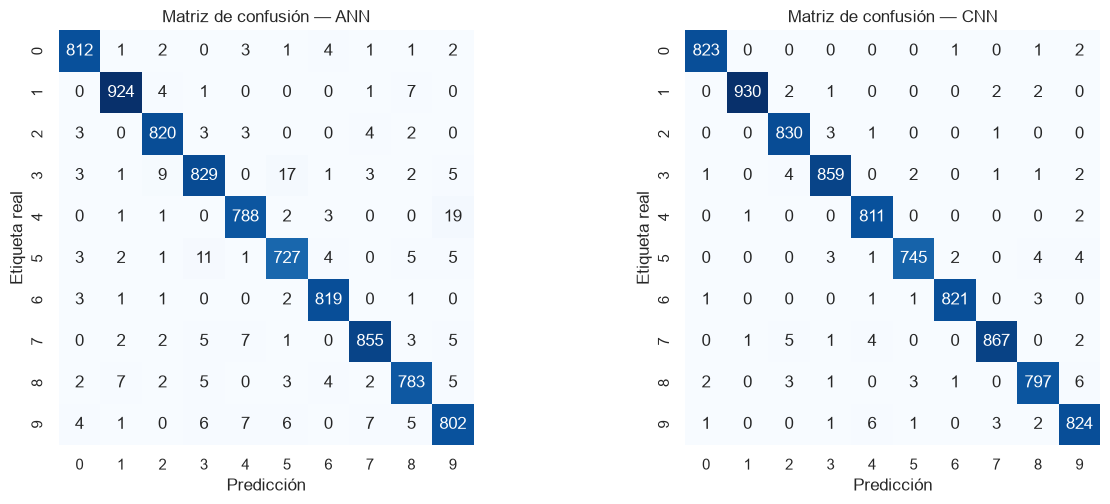


Reporte por clase — ANN


,precision,recall,f1-score,support
0,0.9783,0.9819,0.9801,827.0
1,0.9830,0.9861,0.9845,937.0
2,0.9739,0.9820,0.9779,835.0
3,0.9640,0.9529,0.9584,870.0
4,0.9740,0.9681,0.9710,814.0
5,0.9578,0.9578,0.9578,759.0
6,0.9808,0.9903,0.9856,827.0
7,0.9794,0.9716,0.9755,880.0
8,0.9679,0.9631,0.9655,813.0
9,0.9514,0.9570,0.9542,838.0



Reporte por clase — CNN


,precision,recall,f1-score,support
0,0.9940,0.9952,0.9946,827.0
1,0.9979,0.9925,0.9952,937.0
2,0.9834,0.9940,0.9887,835.0
3,0.9885,0.9874,0.9879,870.0
4,0.9842,0.9963,0.9902,814.0
5,0.9907,0.9816,0.9861,759.0
6,0.9952,0.9927,0.9939,827.0
7,0.9920,0.9852,0.9886,880.0
8,0.9840,0.9803,0.9821,813.0
9,0.9786,0.9833,0.9810,838.0


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
confusion_matrices = {}
classification_reports = {}

for ax, model_name in zip(axes, ["ANN", "CNN"]):
    cm = confusion_matrix(y_test, predictions[model_name])
    confusion_matrices[model_name] = cm
    classification_reports[model_name] = pd.DataFrame(
        classification_report(y_test, predictions[model_name], output_dict=True, zero_division=0)
    ).T
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, square=True)
    ax.set(title=f"Matriz de confusión — {model_name}", xlabel="Predicción", ylabel="Etiqueta real")

plt.tight_layout()
plt.savefig(BASE_DIR / "matrices_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

for model_name in ["ANN", "CNN"]:
    print(f"\nReporte por clase — {model_name}")
    display(classification_reports[model_name].iloc[:10].round(4))

### 11. Análisis de errores

Confusiones más frecuentes — ANN


,Etiqueta real,Predicción,Casos
0,4,9,19
1,3,5,17
2,5,3,11
3,3,2,9
4,9,7,7


Confusiones más frecuentes — CNN


,Etiqueta real,Predicción,Casos
0,8,9,6
1,9,4,6
2,7,2,5
3,7,4,4
4,5,9,4


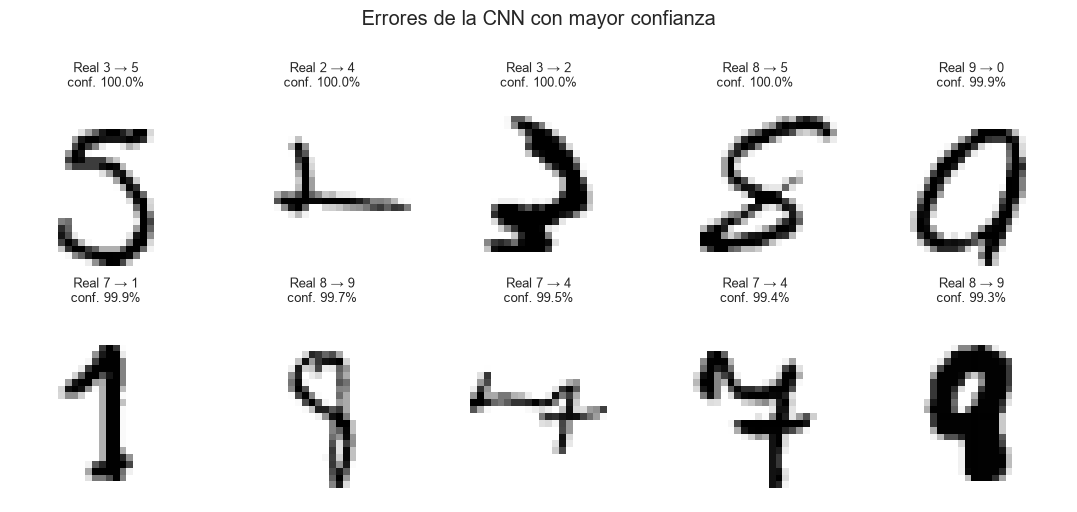

In [14]:
def top_confusions(cm, n=5):
    cm_without_diagonal = cm.copy()
    np.fill_diagonal(cm_without_diagonal, 0)
    ranked = np.dstack(np.unravel_index(np.argsort(cm_without_diagonal.ravel())[::-1], cm.shape))[0]
    rows = []
    for true_digit, predicted_digit in ranked[:n]:
        rows.append({
            "Etiqueta real": int(true_digit),
            "Predicción": int(predicted_digit),
            "Casos": int(cm[true_digit, predicted_digit]),
        })
    return pd.DataFrame(rows)


for model_name in ["ANN", "CNN"]:
    print(f"Confusiones más frecuentes — {model_name}")
    display(top_confusions(confusion_matrices[model_name]))

cnn_errors = np.flatnonzero(predictions["CNN"] != y_test)
ordered_errors = cnn_errors[np.argsort(probabilities["CNN"][cnn_errors].max(axis=1))[::-1]]

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for idx, ax in zip(ordered_errors[:10], axes.ravel()):
    predicted = predictions["CNN"][idx]
    confidence = probabilities["CNN"][idx, predicted]
    ax.imshow(X_test[idx, :, :, 0], cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"Real {y_test[idx]} → {predicted}\nconf. {confidence:.1%}", fontsize=9)
    ax.axis("off")
fig.suptitle("Errores de la CNN con mayor confianza", y=1.02)
plt.tight_layout()
plt.show()

## Conclusiones

### 12. Comparación y selección del mejor enfoque

In [15]:
best_model = metrics_df["F1 macro"].idxmax()
other_model = "ANN" if best_model == "CNN" else "CNN"
f1_gain = metrics_df.loc[best_model, "F1 macro"] - metrics_df.loc[other_model, "F1 macro"]
accuracy_gain = metrics_df.loc[best_model, "Exactitud"] - metrics_df.loc[other_model, "Exactitud"]
relative_time = metrics_df.loc[best_model, "Tiempo entrenamiento (s)"] / metrics_df.loc[other_model, "Tiempo entrenamiento (s)"]

print(
    f"El mejor modelo según F1 macro es {best_model}: "
    f"F1={metrics_df.loc[best_model, 'F1 macro']:.4f} y "
    f"exactitud={metrics_df.loc[best_model, 'Exactitud']:.4f}."
)
print(f"Ventaja absoluta frente a {other_model}: {f1_gain:.4f} en F1 macro y {accuracy_gain:.4f} en exactitud.")
print(f"Su tiempo de entrenamiento fue {relative_time:.2f}× el de {other_model} en este equipo.")

conclusion = (
    f"{best_model} obtuvo el mejor equilibrio entre las diez clases. "
    f"La diferencia de F1 macro fue {f1_gain:.4f} y la diferencia de exactitud {accuracy_gain:.4f}. "
    "La ventaja de la CNN, si resulta ganadora, se explica por la extracción de patrones locales y la conservación de la estructura espacial; "
    "la ANN aplana los píxeles antes de aprender. La contrapartida es un mayor costo computacional."
)
print("\nConclusión:", conclusion)

summary_payload = {
    "semilla": SEED,
    "tamano_prueba": TEST_SIZE,
    "n_entrenamiento": int(len(y_train)),
    "n_prueba": int(len(y_test)),
    "mejor_modelo": best_model,
    "ganancia_f1_absoluta": float(f1_gain),
    "ganancia_exactitud_absoluta": float(accuracy_gain),
    "metricas": metrics_df.reset_index().to_dict(orient="records"),
    "confusiones_principales": {
        name: top_confusions(cm).to_dict(orient="records") for name, cm in confusion_matrices.items()
    },
}
(BASE_DIR / "resultados_resumen.json").write_text(
    json.dumps(summary_payload, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("\nArchivos generados: resultados_metricas.csv, resultados_resumen.json y figuras PNG.")

El mejor modelo según F1 macro es CNN: F1=0.9888 y exactitud=0.9889.
Ventaja absoluta frente a ANN: 0.0178 en F1 macro y 0.0176 en exactitud.
Su tiempo de entrenamiento fue 15.81× el de ANN en este equipo.

Conclusión: CNN obtuvo el mejor equilibrio entre las diez clases. La diferencia de F1 macro fue 0.0178 y la diferencia de exactitud 0.0176. La ventaja de la CNN, si resulta ganadora, se explica por la extracción de patrones locales y la conservación de la estructura espacial; la ANN aplana los píxeles antes de aprender. La contrapartida es un mayor costo computacional.

Archivos generados: resultados_metricas.csv, resultados_resumen.json y figuras PNG.


### Limitaciones y próximos pasos

- La comparación corresponde a una sola partición estratificada; una validación cruzada repetida daría una estimación más completa, pero su costo es alto para redes neuronales.
- El tiempo depende del hardware y de la carga del equipo; se reporta como evidencia operativa, no como propiedad universal del modelo.
- Las arquitecturas son deliberadamente compactas y comparables. Una búsqueda sistemática de hiperparámetros podría mejorar ambos resultados.
- Para un uso real convendría evaluar imágenes externas, variaciones de escritura y calibración de probabilidades.

## Referencias de implementación

- Guías del curso: `transcript clase 01.docx` a `transcript clase 05.docx`; en particular, las clases 04 y 05 para la arquitectura CNN y las instrucciones del laboratorio.
- Dataset local: `train.csv` (42,000 imágenes MNIST de 28×28 píxeles, una etiqueta y 784 columnas de píxeles).
- Librerías empleadas: TensorFlow/Keras, scikit-learn, pandas, NumPy, Matplotlib y Seaborn.